# Notebook 06 — K-Nearest Neighbors para regresión

En este notebook estudiaremos cómo K-Nearest Neighbors (KNN) genera predicciones a partir de observaciones cercanas.

## Objetivos

Al finalizar el notebook deberías ser capaz de:

- explicar la intuición detrás de KNN para regresión;
- calcular manualmente una predicción sencilla;
- ajustar `KNeighborsRegressor`;
- analizar el efecto del hiperparámetro \(k\);
- distinguir entre ponderación uniforme y ponderación por distancia;
- comprender por qué el escalamiento es indispensable;
- visualizar underfitting y overfitting en KNN;
- analizar algunas limitaciones del método, incluida la maldición de la dimensionalidad.

Usaremos datos sintéticos con una relación no lineal.

## 1. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

pd.options.display.float_format = "{:,.4f}".format


## 2. Generación de datos sintéticos

Utilizaremos la función:

\[
f(x)=\sin(1.4x)+0.25x.
\]

Las observaciones incluyen ruido aleatorio:

\[
y=f(x)+\varepsilon.
\]

KNN no intenta estimar una ecuación explícita. Predice utilizando los valores observados alrededor de una nueva observación.

In [2]:
def true_function(x):
    return np.sin(1.4 * x) + 0.25 * x


n_samples = 180

X = rng.uniform(-4, 4, size=(n_samples, 1))
y = true_function(X[:, 0]) + rng.normal(0, 0.30, size=n_samples)

data = pd.DataFrame({
    "x": X[:, 0],
    "y": y,
})

data.head()


,x,y
0,2.1916,0.6691
1,-0.4890,-0.7902
2,2.8688,0.0356
3,1.5789,1.5888
4,-3.2466,0.2402


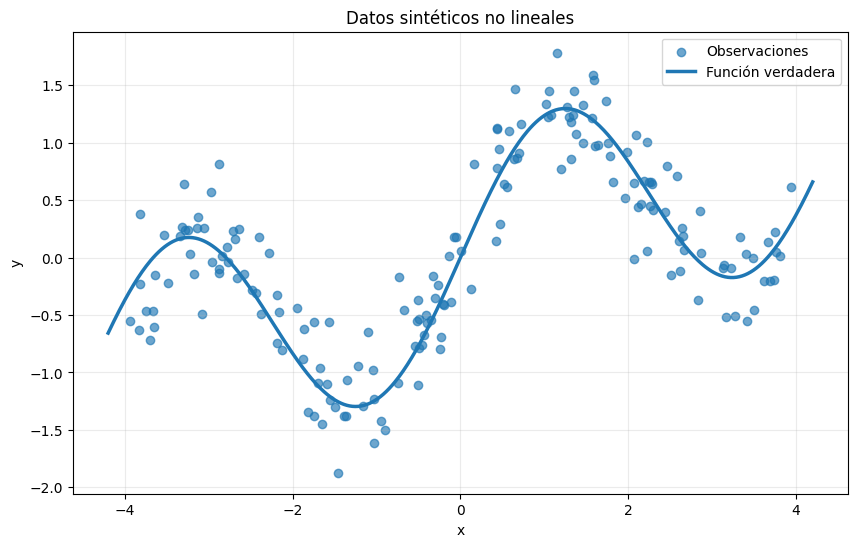

In [3]:
x_grid = np.linspace(-4.2, 4.2, 500)

plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], y, alpha=0.65, label="Observaciones")
plt.plot(
    x_grid,
    true_function(x_grid),
    linewidth=2.5,
    label="Función verdadera",
)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Datos sintéticos no lineales")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 3. ¿Cómo predice KNN?

Para una nueva observación \(x^\ast\):

1. calcula la distancia entre \(x^\ast\) y cada observación de entrenamiento;
2. selecciona los \(k\) vecinos más cercanos;
3. promedia sus valores objetivo.

Con ponderación uniforme:

\[
\widehat{y}(x^\ast)
=
\frac{1}{k}
\sum_{i\in N_k(x^\ast)} y_i.
\]

## 4. Predicción manual

Tomaremos un subconjunto pequeño y calcularemos una predicción sin usar `scikit-learn`.

In [4]:
manual_data = pd.DataFrame({
    "x": [0.0, 1.0, 2.0, 3.0, 4.0],
    "y": [1.0, 1.8, 2.2, 3.7, 4.1],
})

query_x = 2.4
k_manual = 3

manual_data["distancia"] = np.abs(
    manual_data["x"] - query_x
)

manual_data.sort_values("distancia")


,x,y,distancia
2,2.0000,2.2000,0.4000
3,3.0000,3.7000,0.6000
1,1.0000,1.8000,1.4000
4,4.0000,4.1000,1.6000
0,0.0000,1.0000,2.4000


In [5]:
nearest_neighbors = (
    manual_data
    .nsmallest(k_manual, "distancia")
)

manual_prediction = nearest_neighbors["y"].mean()

print("Vecinos seleccionados:")
display(nearest_neighbors)

print(
    f"Predicción manual para x={query_x}: "
    f"{manual_prediction:.3f}"
)


Vecinos seleccionados:


,x,y,distancia
2,2.0000,2.2000,0.4000
3,3.0000,3.7000,0.6000
1,1.0000,1.8000,1.4000


Predicción manual para x=2.4: 2.567


La predicción no proviene de una función paramétrica aprendida, sino del comportamiento local de los datos.

## 5. Split de entrenamiento y prueba

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
)

print(f"Train: {len(X_train)}")
print(f"Test: {len(X_test)}")


Train: 126
Test: 54


## 6. Ajuste de un primer modelo KNN

Comenzaremos con \(k=5\) y ponderación uniforme.

In [7]:
knn_model = KNeighborsRegressor(
    n_neighbors=5,
    weights="uniform",
)

knn_model.fit(X_train, y_train)

train_predictions = knn_model.predict(X_train)
test_predictions = knn_model.predict(X_test)

first_metrics = pd.DataFrame({
    "Métrica": ["MAE", "RMSE", "R²"],
    "Train": [
        mean_absolute_error(y_train, train_predictions),
        mean_squared_error(y_train, train_predictions) ** 0.5,
        r2_score(y_train, train_predictions),
    ],
    "Test": [
        mean_absolute_error(y_test, test_predictions),
        mean_squared_error(y_test, test_predictions) ** 0.5,
        r2_score(y_test, test_predictions),
    ],
})

first_metrics


,Métrica,Train,Test
0,MAE,0.2204,0.2650
1,RMSE,0.2716,0.3204
2,R²,0.8767,0.8296


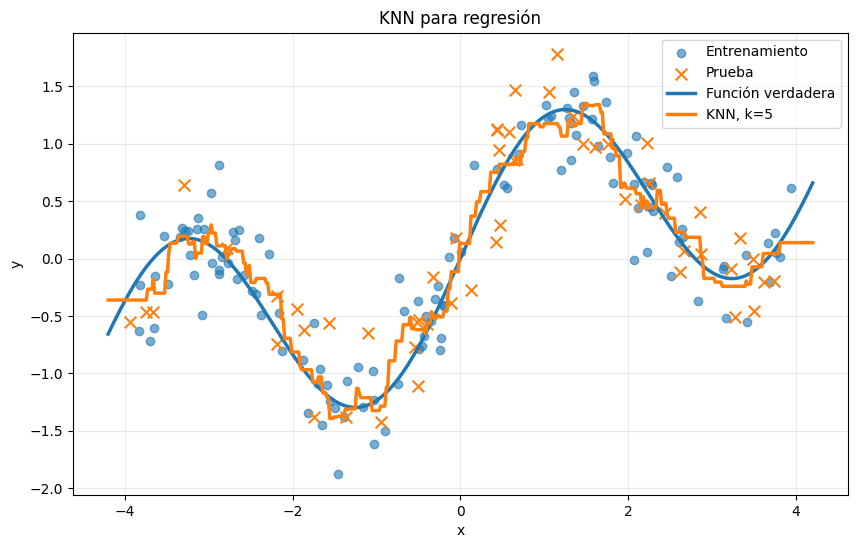

In [8]:
grid_predictions = knn_model.predict(
    x_grid.reshape(-1, 1)
)

plt.figure(figsize=(10, 6))
plt.scatter(
    X_train[:, 0],
    y_train,
    alpha=0.6,
    label="Entrenamiento",
)
plt.scatter(
    X_test[:, 0],
    y_test,
    marker="x",
    s=70,
    label="Prueba",
)
plt.plot(
    x_grid,
    true_function(x_grid),
    linewidth=2.5,
    label="Función verdadera",
)
plt.plot(
    x_grid,
    grid_predictions,
    linewidth=2.5,
    label="KNN, k=5",
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("KNN para regresión")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 7. Efecto del número de vecinos

El hiperparámetro \(k\) controla la suavidad del modelo.

- \(k\) pequeño: predicciones muy locales y flexibles;
- \(k\) grande: predicciones más suaves y estables.

In [9]:
neighbors_to_compare = [1, 3, 5, 10, 25, 60]
neighbor_results = []

for k in neighbors_to_compare:
    model = KNeighborsRegressor(
        n_neighbors=k,
        weights="uniform",
    )
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    neighbor_results.append({
        "k": k,
        "RMSE train": mean_squared_error(
            y_train,
            train_pred,
        ) ** 0.5,
        "RMSE test": mean_squared_error(
            y_test,
            test_pred,
        ) ** 0.5,
        "R² test": r2_score(y_test, test_pred),
    })

neighbor_results_df = pd.DataFrame(neighbor_results)
neighbor_results_df


,k,RMSE train,RMSE test,R² test
0,1,0.0000,0.4519,0.6610
1,3,0.2545,0.3433,0.8044
2,5,0.2716,0.3204,0.8296
3,10,0.2913,0.3290,0.8204
4,25,0.3293,0.3848,0.7543
5,60,0.5981,0.6072,0.3882


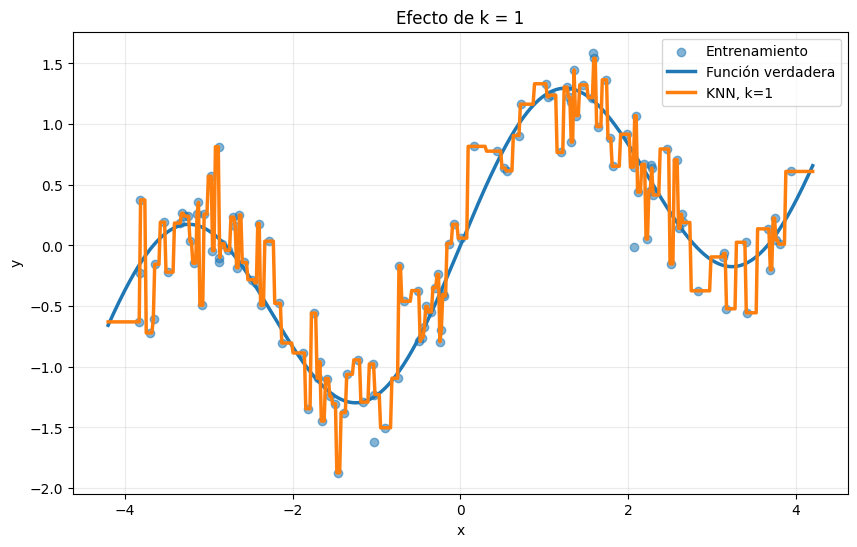

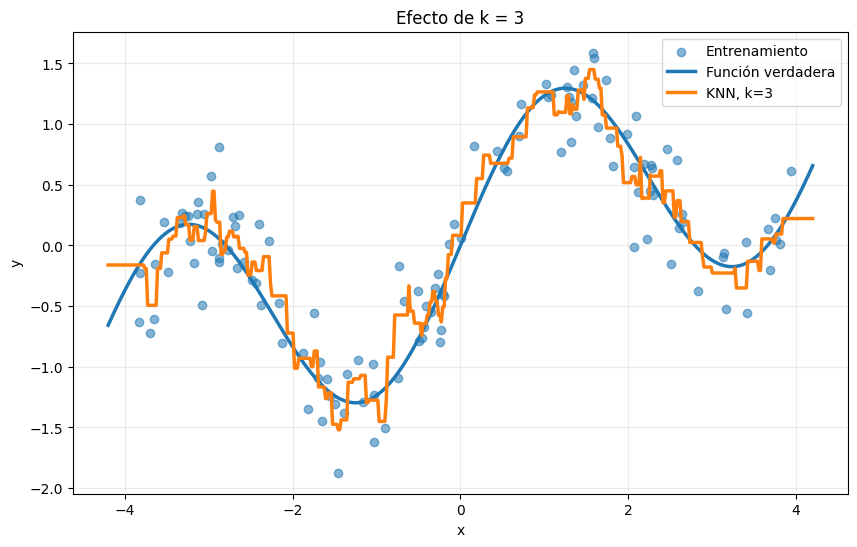

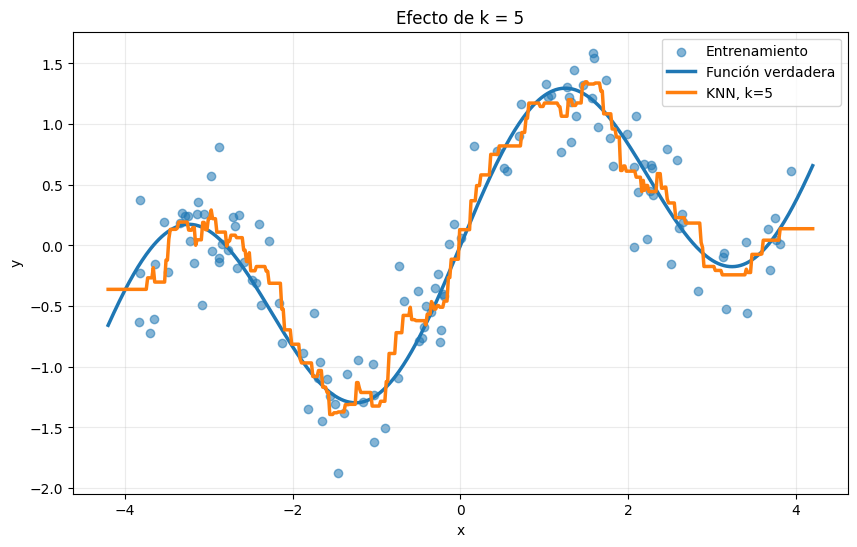

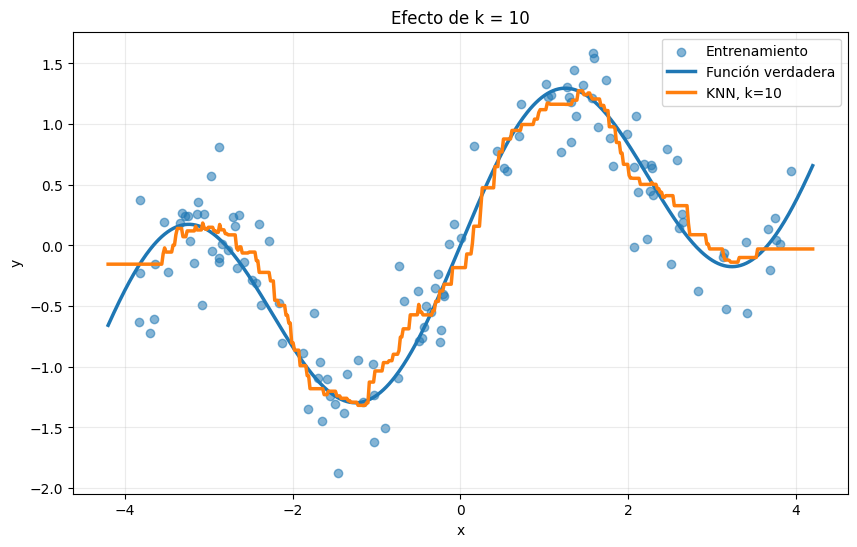

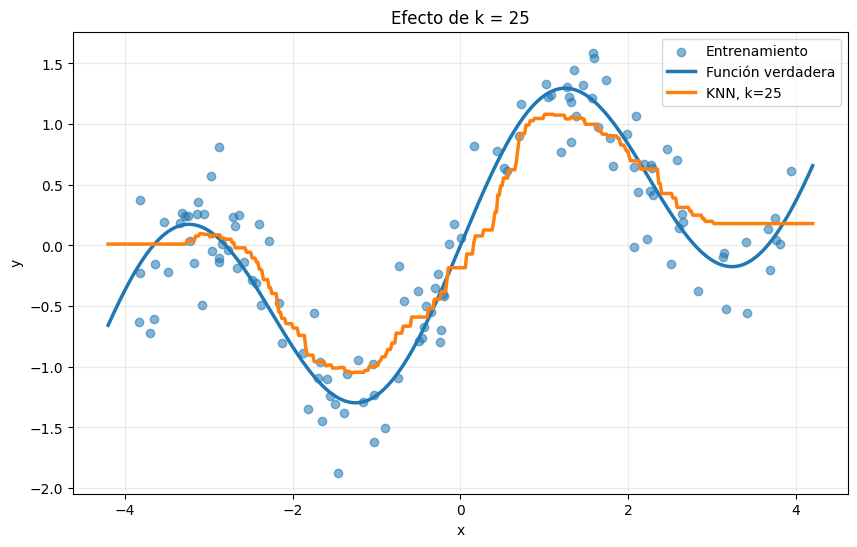

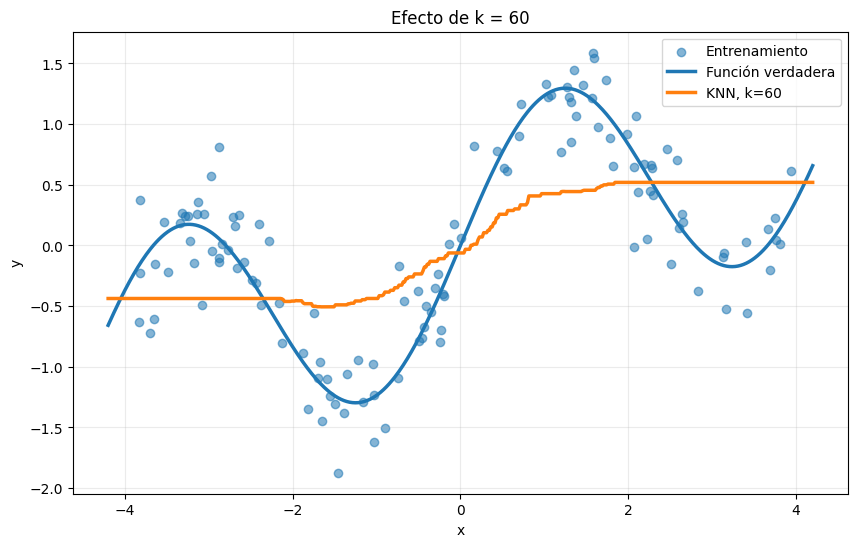

In [10]:
for k in neighbors_to_compare:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    y_grid_pred = model.predict(
        x_grid.reshape(-1, 1)
    )

    plt.figure(figsize=(10, 6))
    plt.scatter(
        X_train[:, 0],
        y_train,
        alpha=0.55,
        label="Entrenamiento",
    )
    plt.plot(
        x_grid,
        true_function(x_grid),
        linewidth=2.5,
        label="Función verdadera",
    )
    plt.plot(
        x_grid,
        y_grid_pred,
        linewidth=2.5,
        label=f"KNN, k={k}",
    )

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(f"Efecto de k = {k}")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


### Interpretación

- \(k=1\) puede memorizar el entrenamiento y mostrar alta varianza.
- Un valor intermedio puede capturar la estructura local.
- Un \(k\) excesivamente grande promedia regiones diferentes y puede generar underfitting.

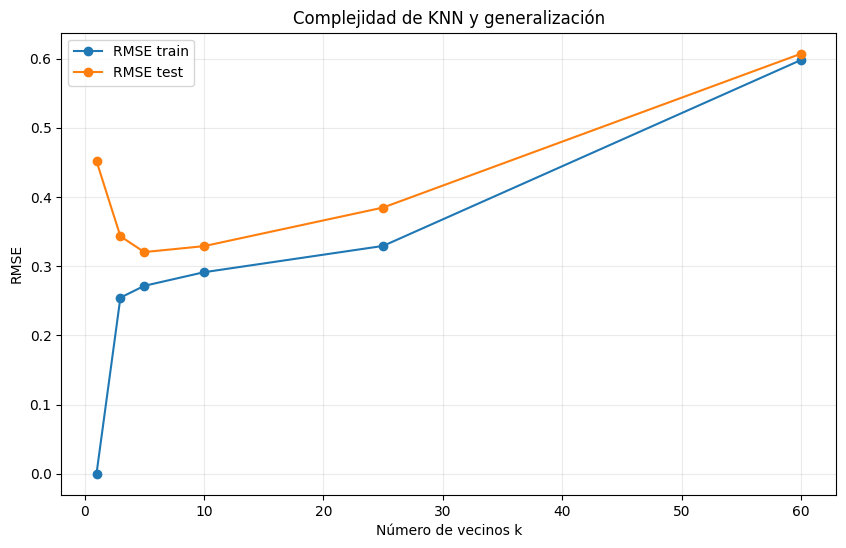

In [11]:
plt.figure(figsize=(10, 6))

plt.plot(
    neighbor_results_df["k"],
    neighbor_results_df["RMSE train"],
    marker="o",
    label="RMSE train",
)

plt.plot(
    neighbor_results_df["k"],
    neighbor_results_df["RMSE test"],
    marker="o",
    label="RMSE test",
)

plt.xlabel("Número de vecinos k")
plt.ylabel("RMSE")
plt.title("Complejidad de KNN y generalización")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 8. Ponderación uniforme vs. distancia

Con `weights="uniform"` todos los vecinos tienen la misma influencia.

Con `weights="distance"` los vecinos más cercanos reciben mayor peso.

In [12]:
weight_results = []

for weight_type in ["uniform", "distance"]:
    model = KNeighborsRegressor(
        n_neighbors=10,
        weights=weight_type,
    )
    model.fit(X_train, y_train)

    test_pred = model.predict(X_test)

    weight_results.append({
        "Ponderación": weight_type,
        "MAE test": mean_absolute_error(
            y_test,
            test_pred,
        ),
        "RMSE test": mean_squared_error(
            y_test,
            test_pred,
        ) ** 0.5,
        "R² test": r2_score(y_test, test_pred),
    })

weight_results_df = pd.DataFrame(weight_results)
weight_results_df


,Ponderación,MAE test,RMSE test,R² test
0,uniform,0.2716,0.3290,0.8204
1,distance,0.3011,0.3626,0.7818


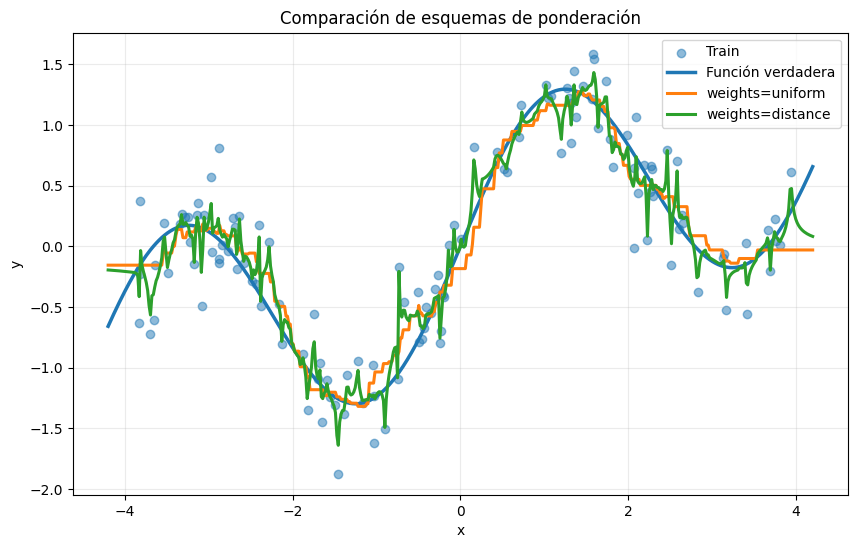

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train[:, 0], y_train, alpha=0.5, label="Train")
plt.plot(
    x_grid,
    true_function(x_grid),
    linewidth=2.5,
    label="Función verdadera",
)

for weight_type in ["uniform", "distance"]:
    model = KNeighborsRegressor(
        n_neighbors=10,
        weights=weight_type,
    )
    model.fit(X_train, y_train)

    plt.plot(
        x_grid,
        model.predict(x_grid.reshape(-1, 1)),
        linewidth=2.2,
        label=f"weights={weight_type}",
    )

plt.xlabel("x")
plt.ylabel("y")
plt.title("Comparación de esquemas de ponderación")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 9. Importancia del escalamiento

KNN utiliza distancias. Una variable con valores numéricos muy grandes puede dominar completamente el cálculo.

Construiremos un problema con dos variables en escalas muy diferentes.

In [14]:
n_scale = 500

x1 = rng.normal(0, 1, size=n_scale)
x2 = rng.normal(0, 1, size=n_scale)

X_scale = pd.DataFrame({
    "variable_pequena": x1,
    "variable_grande": x2 * 100_000,
})

y_scale = (
    5 * x1
    + 5 * x2
    + rng.normal(0, 0.8, size=n_scale)
)

X_scale_train, X_scale_test, y_scale_train, y_scale_test = (
    train_test_split(
        X_scale,
        y_scale,
        test_size=0.30,
        random_state=RANDOM_STATE,
    )
)


In [15]:
knn_without_scaling = KNeighborsRegressor(
    n_neighbors=8
)
knn_without_scaling.fit(
    X_scale_train,
    y_scale_train,
)

knn_with_scaling = Pipeline([
    ("scaler", StandardScaler()),
    (
        "knn",
        KNeighborsRegressor(
            n_neighbors=8,
        ),
    ),
])

knn_with_scaling.fit(
    X_scale_train,
    y_scale_train,
)

scale_results = pd.DataFrame({
    "Modelo": [
        "KNN sin escalamiento",
        "KNN con escalamiento",
    ],
    "RMSE test": [
        mean_squared_error(
            y_scale_test,
            knn_without_scaling.predict(
                X_scale_test
            ),
        ) ** 0.5,
        mean_squared_error(
            y_scale_test,
            knn_with_scaling.predict(
                X_scale_test
            ),
        ) ** 0.5,
    ],
    "R² test": [
        r2_score(
            y_scale_test,
            knn_without_scaling.predict(
                X_scale_test
            ),
        ),
        r2_score(
            y_scale_test,
            knn_with_scaling.predict(
                X_scale_test
            ),
        ),
    ],
})

scale_results


,Modelo,RMSE test,R² test
0,KNN sin escalamiento,4.9682,0.4279
1,KNN con escalamiento,1.1930,0.9670


El escalamiento debe formar parte de un `Pipeline` para que sus parámetros se aprendan únicamente con entrenamiento.

## 10. Inspección de vecinos de una observación

Podemos consultar qué observaciones utiliza el modelo para una predicción.

In [16]:
query_point = np.array([[1.25]])

distances, indices = knn_model.kneighbors(
    query_point,
    n_neighbors=5,
)

neighbor_table = pd.DataFrame({
    "Índice en train": indices[0],
    "x vecino": X_train[indices[0], 0],
    "y vecino": y_train[indices[0]],
    "Distancia": distances[0],
})

neighbor_table


,Índice en train,x vecino,y vecino,Distancia
0,106,1.2754,1.3057,0.0254
1,73,1.2953,1.2209,0.0453
2,118,1.1988,0.7669,0.0512
3,72,1.3145,1.1797,0.0645
4,65,1.3188,0.8529,0.0688


In [17]:
query_prediction = knn_model.predict(
    query_point
)[0]

print(
    f"Predicción para x={query_point[0, 0]:.2f}: "
    f"{query_prediction:.4f}"
)
print(
    f"Promedio de y de los vecinos: "
    f"{neighbor_table['y vecino'].mean():.4f}"
)


Predicción para x=1.25: 1.0652
Promedio de y de los vecinos: 1.0652


## 11. KNN y extrapolación

KNN no extrapola una tendencia más allá de los datos observados. Una predicción fuera del rango disponible depende de los vecinos de los extremos.

In [18]:
extrapolation_points = np.array([
    [-7.0],
    [-5.0],
    [5.0],
    [7.0],
])

extrapolation_predictions = knn_model.predict(
    extrapolation_points
)

pd.DataFrame({
    "x": extrapolation_points[:, 0],
    "Predicción KNN": extrapolation_predictions,
    "Función verdadera": true_function(
        extrapolation_points[:, 0]
    ),
})


,x,Predicción KNN,Función verdadera
0,-7.0000,-0.3616,-1.3835
1,-5.0000,-0.3616,-1.9070
2,5.0000,0.1382,1.9070
3,7.0000,0.1382,1.3835


Esta limitación es importante cuando el objetivo requiere predecir en regiones no cubiertas por los datos históricos.

## 12. Maldición de la dimensionalidad

Al aumentar el número de variables:

- las observaciones tienden a verse relativamente lejanas;
- se necesitan más datos para cubrir el espacio;
- la noción de “vecino cercano” pierde fuerza.

Realizaremos un experimento sintético manteniendo constante el tamaño de muestra.

In [19]:
dimension_results = []

for n_features in [1, 2, 5, 10, 20, 50]:
    X_dim = rng.normal(
        size=(1_200, n_features)
    )

    informative_features = min(
        n_features,
        3,
    )

    y_dim = (
        X_dim[:, :informative_features].sum(axis=1)
        + rng.normal(0, 0.6, size=1_200)
    )

    X_dim_train, X_dim_test, y_dim_train, y_dim_test = (
        train_test_split(
            X_dim,
            y_dim,
            test_size=0.30,
            random_state=RANDOM_STATE,
        )
    )

    model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "knn",
            KNeighborsRegressor(
                n_neighbors=10,
            ),
        ),
    ])

    model.fit(X_dim_train, y_dim_train)
    predictions_dim = model.predict(
        X_dim_test
    )

    dimension_results.append({
        "Número de variables": n_features,
        "RMSE test": mean_squared_error(
            y_dim_test,
            predictions_dim,
        ) ** 0.5,
        "R² test": r2_score(
            y_dim_test,
            predictions_dim,
        ),
    })

dimension_results_df = pd.DataFrame(
    dimension_results
)

dimension_results_df


,Número de variables,RMSE test,R² test
0,1,0.5966,0.7274
1,2,0.6456,0.8264
2,5,0.8165,0.8076
3,10,1.0701,0.6923
4,20,1.1867,0.5757
5,50,1.4521,0.3244


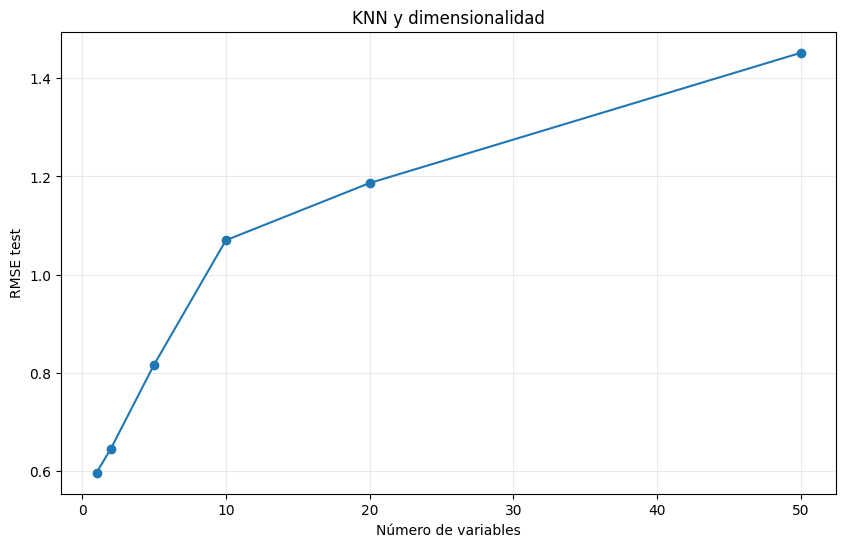

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(
    dimension_results_df["Número de variables"],
    dimension_results_df["RMSE test"],
    marker="o",
)
plt.xlabel("Número de variables")
plt.ylabel("RMSE test")
plt.title("KNN y dimensionalidad")
plt.grid(alpha=0.25)
plt.show()


## 13. Costo computacional

KNN suele describirse como un algoritmo de aprendizaje “perezoso”:

- el entrenamiento es muy rápido;
- las observaciones deben almacenarse;
- predecir requiere buscar vecinos;
- el costo de predicción aumenta con el tamaño del entrenamiento.

Esto contrasta con modelos paramétricos, que condensan la información en un conjunto pequeño de parámetros.

## 14. Errores frecuentes

1. Aplicar KNN sin escalar.
2. Elegir \(k\) usando el conjunto de test.
3. Suponer que \(k=1\) siempre es mejor porque ajusta perfectamente.
4. Utilizar demasiadas variables irrelevantes.
5. Ignorar el costo de predicción.
6. Esperar extrapolación fuera del rango observado.
7. Usar una medida de distancia inapropiada.
8. No revisar observaciones duplicadas o empates.
9. Interpretar KNN como un modelo global.
10. Usar KNN en alta dimensión sin suficiente información.

## 15. Experimentos sugeridos

### Experimento 1

Prueba valores de \(k\) entre 1 y 80.

### Experimento 2

Cambia el nivel de ruido.

### Experimento 3

Compara:

```python
weights="uniform"
weights="distance"
```

### Experimento 4

Modifica la métrica de distancia usando `p=1` y `p=2`.

- `p=1`: Manhattan.
- `p=2`: Euclidiana.

### Experimento 5

Agrega variables irrelevantes y observa el cambio.

### Experimento 6

Aumenta el tamaño de muestra y verifica si mejora el desempeño en alta dimensión.

### Experimento 7

Compara KNN contra regresión lineal sobre la misma relación no lineal.

### Experimento 8

Mide el tiempo de predicción al aumentar el conjunto de entrenamiento.

## 16. Resumen

En este notebook:

- calculamos manualmente una predicción;
- ajustamos `KNeighborsRegressor`;
- estudiamos el efecto de \(k\);
- comparamos ponderación uniforme y por distancia;
- mostramos la importancia del escalamiento;
- inspeccionamos los vecinos utilizados;
- analizamos la falta de extrapolación;
- ilustramos la maldición de la dimensionalidad;
- discutimos su costo computacional.

KNN es flexible e intuitivo, pero su desempeño depende fuertemente de la representación, la escala, la dimensión y la densidad de los datos.